# Student Performance Regression Task-1 

**Purpose**
Build regression models to predict students' exam scores using the Kaggle dataset **Student Performance Factors**. The notebook covers data loading, cleaning, visualization, feature engineering, model training, evaluation, polynomial regression comparison, and experiments with feature combinations.

## Dataset Overview

Dataset link: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

**Source**: Kaggle — *Student Performance Factors*  

| Category                | Item                     | Details                                                                                                                                                                                                                                            |
| ----------------------- | ------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Dataset Info**        | Dataset Name             | Student Performance Factors                                                                                                                                                                                                                        |
|                         | Source                   | Kaggle                                                                                                                                                                                                                                             |
|                         | Total Students (Rows)    | 6,607                                                                                                                                                                                                                                              |
|                         | Total Features (Columns) | 20                                                                                                                                                                                                                                                 |
|                         | Memory Usage             | ~1.0 MB                                                                                                                                                                                                                                            |
|                         | ML Problem Type          | Regression                                                                                                                                                                                                                                         |
| **Target Variable**     | Target Column            | Exam_Score                                                                                                                                                                                                                                         |
|                         | Target Type              | Numerical (int64)                                                                                                                                                                                                                                  |
| **Feature Types**       | Numerical Features       | 7                                                                                                                                                                                                                                                  |
|                         | Categorical Features     | 13                                                                                                                                                                                                                                                 |
| **Numerical Columns**   | Column Names             | Hours_Studied, Attendance, Sleep_Hours, Previous_Scores, Tutoring_Sessions, Physical_Activity, Exam_Score                                                                                                                                          |
| **Categorical Columns** | Column Names             | Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Motivation_Level, Internet_Access, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Learning_Disabilities, Parental_Education_Level, Distance_from_Home, Gender |
| **Missing Values**      | Teacher_Quality          | 78 missing                                                                                                                                                                                                                                         |
|                         | Parental_Education_Level | 90 missing                                                                                                                                                                                                                                         |
|                         | Distance_from_Home       | 67 missing                                                                                                                                                                                                                                         |
| **Gender Distribution** | Male                     | 3,814                                                                                                                                                                                                                                              |
|                         | Female                   | 2,793                                                                                                                                                                                                                                              |
| **Use Case**            | Purpose                  | Predict students’ exam scores using study-related and background factors                                                                                                                                                                           |


In [14]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.style.use("seaborn-v0_8")

In [15]:
# Load dataset
csv_path = "/kaggle/input/student-performance-factors/StudentPerformanceFactors.csv"

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()


Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [16]:
# Basic info and missing values
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 10):")
print(missing.head(10))

Columns:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         o

In [17]:
# Data cleaning
# 1) Normalize column names (optional, keeps analysis consistent)
original_columns = df.columns.tolist()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# 2) Drop duplicates (if any)
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows")

# 3) Quick summary after cleaning
print("New columns:", df.columns.tolist())
print("Shape:", df.shape)

Dropped 0 duplicate rows
New columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
Shape: (6607, 20)


In [18]:
# Summary statistics for numeric features
numeric_summary = df.select_dtypes(include=["number"]).describe().T
numeric_summary.head(10)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [19]:
# Identify target column
# The Kaggle dataset typically uses one of these names.
possible_targets = [
    "Exam_Score", "ExamScore", "Final_Score", "FinalScore", "Score"
]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(
        "Target column not found. Please check the dataset column names."
    )

print("Using target column:", target_col)

Using target column: Exam_Score


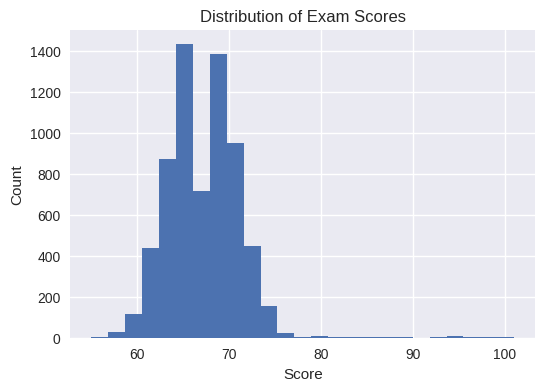

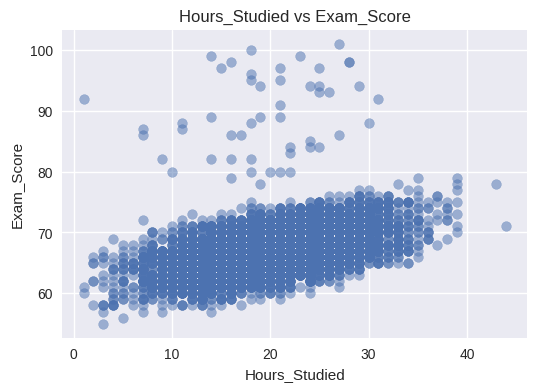

In [20]:
# Basic visualization
plt.figure(figsize=(6, 4))
df[target_col].hist(bins=25)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# Scatter: study hours vs score (if present)
study_cols = ["Hours_Studied", "Study_Hours", "StudyHours"]
study_col = next((c for c in study_cols if c in df.columns), None)

if study_col:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[study_col], df[target_col], alpha=0.5)
    plt.title(f"{study_col} vs {target_col}")
    plt.xlabel(study_col)
    plt.ylabel(target_col)
    plt.show()
else:
    print("Study hours column not found for scatter plot.")

## Modeling

**Evaluation metrics**: MAE, RMSE, and R².  
Lower MAE/RMSE and higher R² indicate better performance.

In [21]:
# Split features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5285, 19)
Test shape: (1322, 19)


In [22]:
# Preprocessing setup (numeric + categorical)
num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# Evaluation helper
def evaluate_model(model, X_te, y_te, label):
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    # RMSE computed manually for compatibility with older scikit-learn
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    print(f"{label}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

Numeric features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## Missing Value Handling

In this project, missing values were handled using **imputation inside the preprocessing pipeline** so that the model can train without errors.



### Numeric Features → Median Imputation
- **Why median?** Median is robust to outliers and represents the middle value of the data.  
- **Steps:**  
  1. Identify numeric columns.  
  2. Compute median for each numeric column.  
  3. Replace missing values with the median.  

- **Example:**
  
Values = [2, 4, 6, NaN, 8]

Median = (4 + 6)/2 = 5

Missing value → 5


**Categorical Features → Mode (Most Frequent) Imputation**  
- **Why mode?** Categorical data has no numeric average, so the most common category is used.  
- **Steps:**  
  1. Identify categorical columns.  
  2. Find the most frequent value (mode).  
  3. Replace missing values with the mode.  
- **Example:**  
Values = ["Yes", "No", "Yes", NaN, "Yes"]

Mode = "Yes"

Missing value → "Yes"

In [23]:
# Linear regression model
lin_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)

results = []
results.append(evaluate_model(lin_reg, X_test, y_test, "Linear Regression"))

Linear Regression: MAE=0.452, RMSE=1.804, R2=0.770


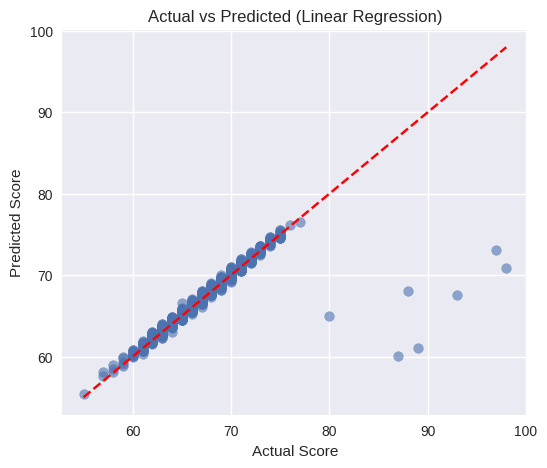

In [24]:
# Visualize predictions vs actual
preds = lin_reg.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted (Linear Regression)")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

In [25]:
# Polynomial regression (degree 2) for numeric features
poly_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

preprocess_poly = ColumnTransformer(
    transformers=[
        ("num", poly_numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

poly_reg = Pipeline(steps=[
    ("preprocess", preprocess_poly),
    ("model", LinearRegression())
])

poly_reg.fit(X_train, y_train)
results.append(evaluate_model(poly_reg, X_test, y_test, "Polynomial Regression (deg=2)"))

Polynomial Regression (deg=2): MAE=0.469, RMSE=1.811, R2=0.768


In [26]:
# Compare model performance
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,model,MAE,RMSE,R2
0,Linear Regression,0.452392,1.804445,0.769650
1,Polynomial Regression (deg=2),0.469406,1.810689,0.768053


In [27]:
# Feature combination experiments
# We will test removing sleep or participation-related features if they exist.

feature_sets = {
    "All Features": X.columns.tolist(),
}

# Helper to safely drop columns if they exist
sleep_cols = ["Sleep_Hours", "SleepHours", "Sleep"]
participation_cols = ["Participation", "Extracurricular_Activities", "Extracurricular"]

sleep_col = next((c for c in sleep_cols if c in X.columns), None)
part_col = next((c for c in participation_cols if c in X.columns), None)

if sleep_col:
    feature_sets["No Sleep"] = [c for c in X.columns if c != sleep_col]
if part_col:
    feature_sets["No Participation"] = [c for c in X.columns if c != part_col]
if sleep_col and part_col:
    feature_sets["No Sleep + No Participation"] = [
        c for c in X.columns if c not in [sleep_col, part_col]
    ]

# Evaluate each feature set using linear regression
combo_results = []

for name, cols in feature_sets.items():
    X_train_fs = X_train[cols]
    X_test_fs = X_test[cols]

    num_fs = X_train_fs.select_dtypes(include=["number"]).columns.tolist()
    cat_fs = X_train_fs.select_dtypes(exclude=["number"]).columns.tolist()

    preprocess_fs = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_fs),
            ("cat", categorical_transformer, cat_fs),
        ]
    )

    model_fs = Pipeline(steps=[
        ("preprocess", preprocess_fs),
        ("model", LinearRegression())
    ])

    model_fs.fit(X_train_fs, y_train)
    res = evaluate_model(model_fs, X_test_fs, y_test, name)
    combo_results.append(res)

combo_results_df = pd.DataFrame(combo_results).sort_values(by="RMSE")
combo_results_df

All Features: MAE=0.452, RMSE=1.804, R2=0.770
No Sleep: MAE=0.451, RMSE=1.804, R2=0.770
No Participation: MAE=0.503, RMSE=1.818, R2=0.766
No Sleep + No Participation: MAE=0.502, RMSE=1.817, R2=0.766


,model,MAE,RMSE,R2
1,No Sleep,0.451374,1.803701,0.769839
0,All Features,0.452392,1.804445,0.769650
3,No Sleep + No Participation,0.502003,1.816999,0.766433
2,No Participation,0.502936,1.817745,0.766241
